In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./dados_vendas_pe_ce_ba.csv")

# Exibição das primeiras linhas da tabela

In [3]:
df.head()

,ID,Estado,Cidade,Categoria,Quantidade,Valor_Venda
0,1,BA,Salvador,Alimentos,4,754.47
1,2,PE,Recife,Roupas,9,147.37
2,3,PE,Petrolina,Eletrônicos,2,80.19
3,4,PE,Recife,Roupas,9,621.92
4,5,PE,Petrolina,Roupas,7,716.26


# Quantidade de linhas e colunas da tabela

In [4]:
df.shape

(30, 6)

# Os tipos de dados de cada coluna

In [5]:
df.dtypes

ID               int64
Estado             str
Cidade             str
Categoria          str
Quantidade       int64
Valor_Venda    float64
dtype: object

# Verificação de existência de valores nulos na tabela

In [6]:
df.isnull().sum()

ID             0
Estado         0
Cidade         0
Categoria      0
Quantidade     0
Valor_Venda    0
dtype: int64

# Verificação de valores duplicados na tabela

In [24]:
df.duplicated().sum()

np.int64(0)

# Estatísticas descritivas

In [25]:
df.describe()

,ID,Quantidade,Valor_Venda
count,30.000000,30.000000,30.000000
mean,15.500000,5.400000,496.509667
std,8.803408,3.012617,282.601654
min,1.000000,1.000000,80.190000
25%,8.250000,3.000000,261.672500
50%,15.500000,6.000000,446.640000
75%,22.750000,7.000000,745.687500
max,30.000000,10.000000,985.960000


# Estado que realizou o maior número de vendas

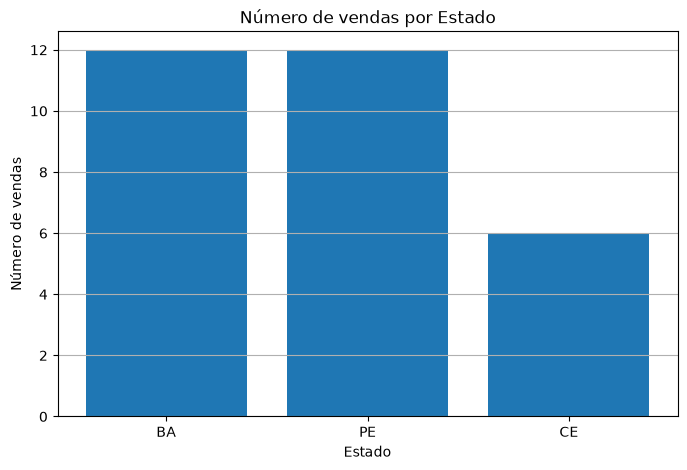

In [9]:
vendas_por_estado = df["Estado"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(vendas_por_estado.index, vendas_por_estado.values)
plt.title("Número de vendas por Estado")
plt.xlabel("Estado")
plt.ylabel("Número de vendas")
plt.grid(axis="y")
plt.show()

# Faturamento por estado

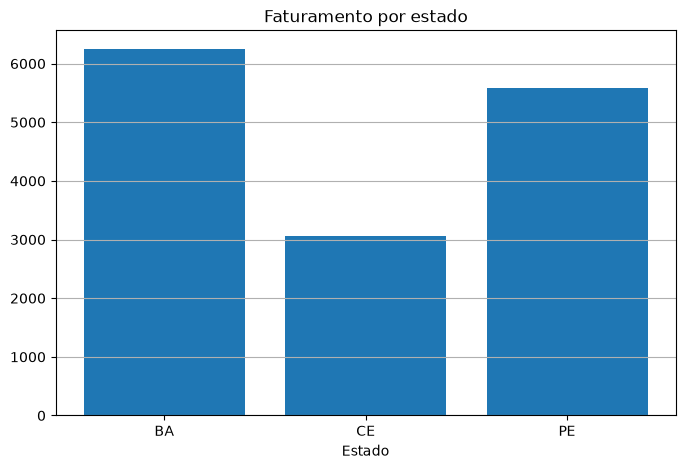

In [ ]:
faturamento_estado = (
    df.groupby("Estado")["Valor_Venda"].sum().reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(faturamento_estado["Estado"], faturamento_estado["Valor_Venda"])
plt.title("Faturamento por estado")
plt.xlabel("Estado")
plt.grid(axis="y")
plt.show()

# Estado que apresentou a maior quantidade total de produtos vendidos

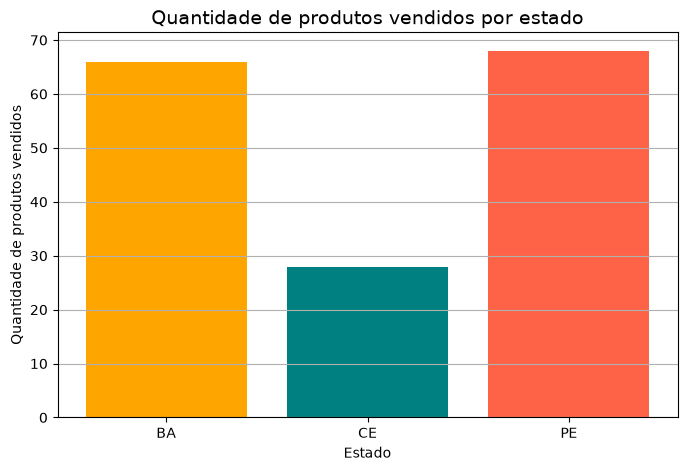

In [11]:
produto_por_estado = (
    df.groupby("Estado")["Quantidade"].sum().reset_index()
)

cores = [
    "orange" if estado == "BA" else "teal" if estado == "CE" else "tomato"
    for estado in produto_por_estado["Estado"]
]

plt.figure(figsize=(8, 5))
plt.bar(produto_por_estado["Estado"], produto_por_estado["Quantidade"], color=cores)
plt.title(f"Quantidade de produtos vendidos por estado", fontsize=14)
plt.xlabel("Estado")
plt.ylabel("Quantidade de produtos vendidos")
plt.grid(axis='y')
plt.show()

# Categoria que possui mais vendas

Vendas por categoria
Alimentos: 11
Roupas: 10
Eletrônicos: 9


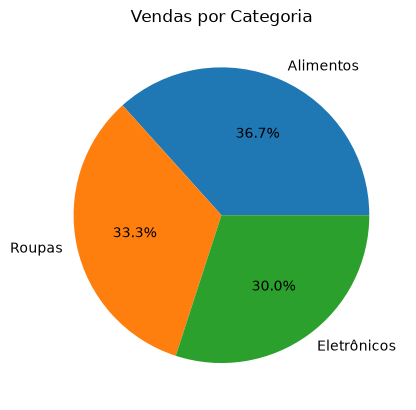

In [12]:
vendas_por_categoria = df["Categoria"].value_counts()

print("Vendas por categoria")
for categoria, qtdv in zip(vendas_por_categoria.index, vendas_por_categoria.values):
    print(f"{categoria}: {qtdv}")

plt.pie(vendas_por_categoria.values,  labels=vendas_por_categoria.index, autopct="%1.1f%%")
plt.title("Vendas por Categoria")
plt.show()

# Faturamento por categoria

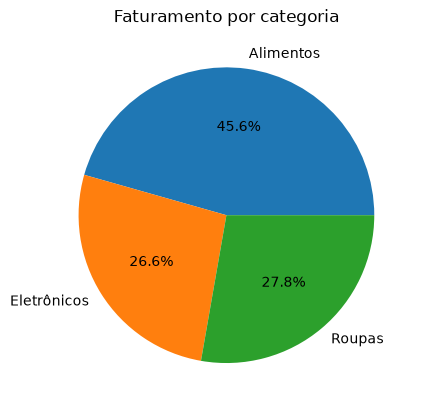

,Categoria,Valor_Venda
0,Alimentos,6791.82
1,Eletrônicos,3969.50
2,Roupas,4133.97


In [13]:
faturamento_cat = (
    df.groupby("Categoria")["Valor_Venda"].sum().reset_index()
)

plt.pie(faturamento_cat["Valor_Venda"], labels=faturamento_cat["Categoria"], autopct="%1.1f%%")
plt.title("Faturamento por categoria")
plt.show()

faturamento_cat.head()

# Categoria que vendeu mais unidades

Produtos por categoria
Alimentos: 60
Eletrônicos: 48
Roupas: 54


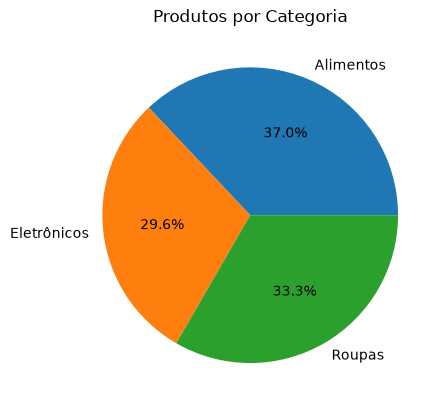

In [14]:
produtos_por_categoria = (
    df.groupby("Categoria")["Quantidade"].sum().reset_index()
)

print("Produtos por categoria")
for categoria, qtdp in zip(produtos_por_categoria["Categoria"], produtos_por_categoria["Quantidade"]):
    print(f"{categoria}: {qtdp}")

plt.pie(produtos_por_categoria["Quantidade"], labels=produtos_por_categoria["Categoria"], autopct="%1.1f%%")
plt.title("Produtos por Categoria")
plt.show()

# Faturamento por cidade

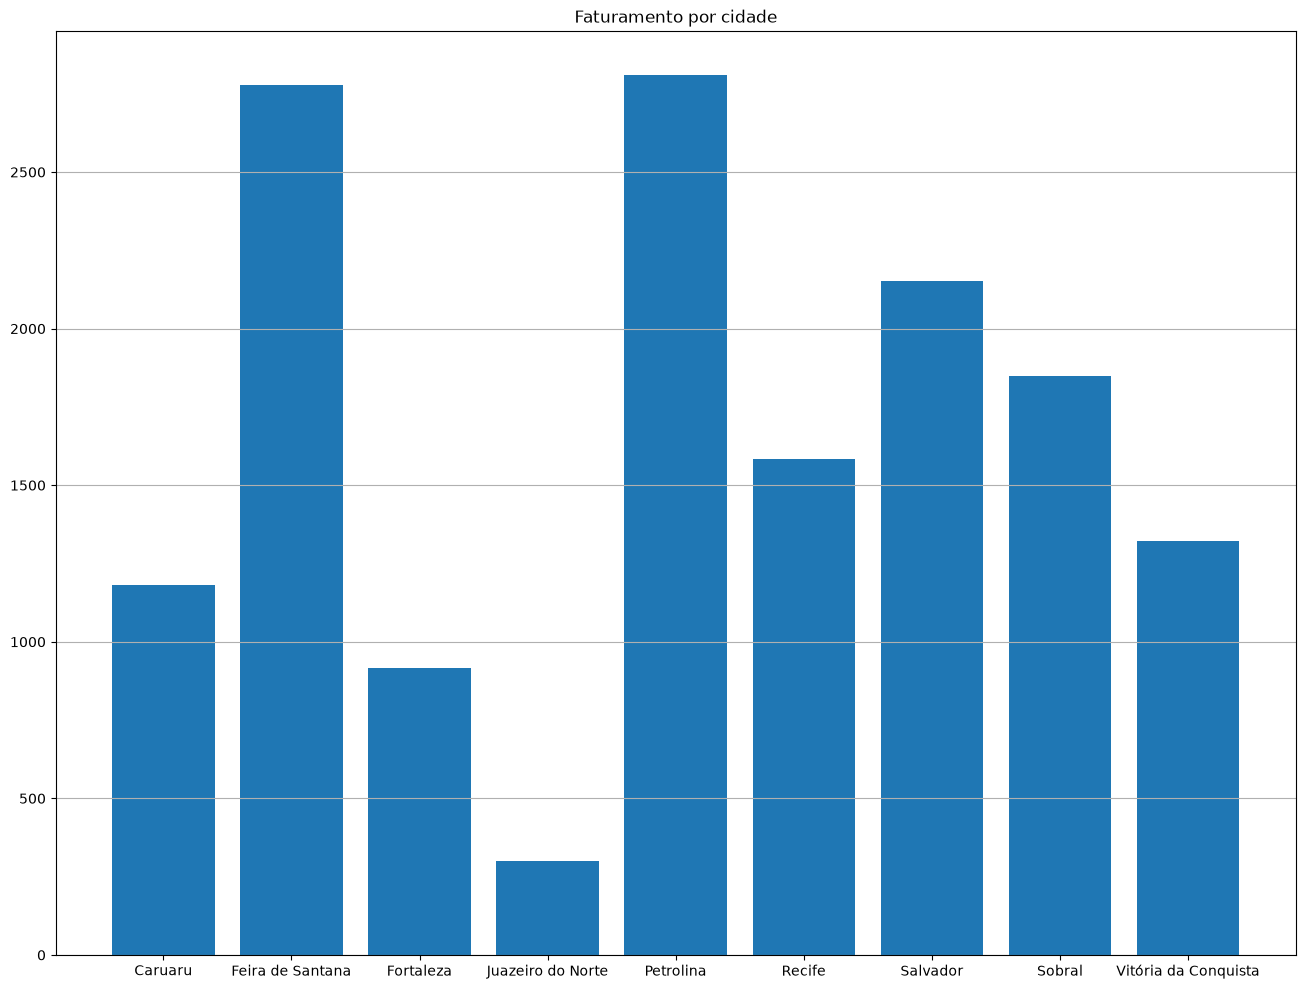

In [15]:
faturamento_cidade = (
    df.groupby("Cidade")["Valor_Venda"].sum().reset_index()
)

plt.figure(figsize=(16, 12))
plt.bar(faturamento_cidade["Cidade"], faturamento_cidade["Valor_Venda"])
plt.title("Faturamento por cidade")
plt.grid(axis='y')
plt.show()

# Cidade que realizou o maior número de vendas

In [16]:
vendas_por_cidade = df["Cidade"].value_counts()

vendas_por_cidade.head(9)

Cidade
Petrolina               5
Feira de Santana        5
Caruaru                 4
Sobral                  4
Vitória da Conquista    4
Salvador                3
Recife                  3
Juazeiro do Norte       1
Fortaleza               1
Name: count, dtype: int64

# Cidade que vendeu mais produtos

In [17]:
produtos_por_cidade = (
    df.groupby("Cidade")["Quantidade"].sum().reset_index()
)

produtos_por_cidade.head(9)

,Cidade,Quantidade
0,Caruaru,14
1,Feira de Santana,21
2,Fortaleza,10
3,Juazeiro do Norte,1
4,Petrolina,29
5,Recife,25
6,Salvador,16
7,Sobral,17
8,Vitória da Conquista,29


# Distribuição dos valores de venda

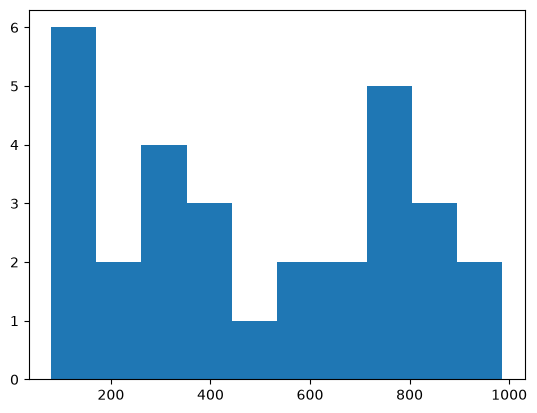

In [18]:
plt.hist(df["Valor_Venda"])
plt.show()

Sim, existem muitas vendas pequenas. Está no meio termo a cerca da quantidade de vendas altas. Há a possibilidade de os dados estarem concentrados na faixa de menos de 200.00 e também entre 700.00 e 800.00.

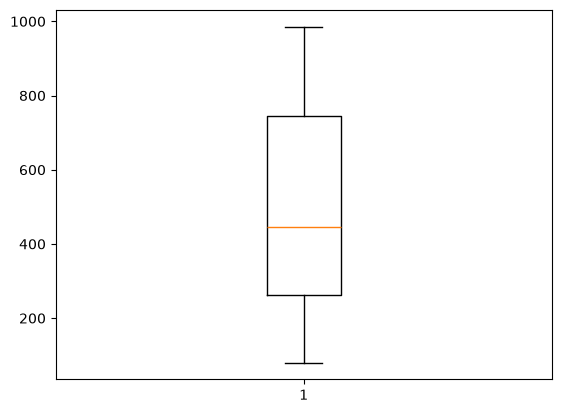

In [19]:
plt.boxplot(df["Valor_Venda"])
plt.show()

Não há outliers. 

# Faturamento por estado

In [20]:
faturamento_estado = (
    df.groupby("Estado")["Valor_Venda"].sum().reset_index()
)

faturamento_estado.head()


,Estado,Valor_Venda
0,BA,6251.87
1,CE,3067.08
2,PE,5576.34


# Faturamento por categoria

In [21]:
faturamento_cat = (
    df.groupby("Categoria")["Valor_Venda"].sum().reset_index()
)

faturamento_cat.head()


,Categoria,Valor_Venda
0,Alimentos,6791.82
1,Eletrônicos,3969.50
2,Roupas,4133.97


# Quantidade de produtos vendidos por cidade

In [22]:
qtd_vendida = (
    df.groupby("Cidade")["Quantidade"].sum().reset_index()
)

qtd_vendida.head(9)

,Cidade,Quantidade
0,Caruaru,14
1,Feira de Santana,21
2,Fortaleza,10
3,Juazeiro do Norte,1
4,Petrolina,29
5,Recife,25
6,Salvador,16
7,Sobral,17
8,Vitória da Conquista,29


# Média de vendas por estado

In [23]:
vendas = (
    df.groupby("Estado")["Valor_Venda"].sum().reset_index()
)

media = (
    df.groupby("Estado")["Valor_Venda"].mean().reset_index()
)

vendas["Media_Vendas"] = media["Valor_Venda"]
vendas.head()

,Estado,Valor_Venda,Media_Vendas
0,BA,6251.87,520.989167
1,CE,3067.08,511.180000
2,PE,5576.34,464.695000


# Interpretação Final

O estado que apresentou o melhor desempenho: Bahia.

Ao observar os gráficos de análise por estado, tem-se que os estados da Bahia e Pernambuco teve a mesma quantidade de vendas. Porém o estado da Bahia teve o maior faturamento. Somente na análise por quantidade de produtos vendidos que o Pernambuco ultrapassou a Bahia, mas por pouco.

Categoria que foi a mais lucrativa: Alimentos. Foi a categoria que mais se destacou entre as demais. 

Existem diferenças significativas entre os estados, ao observar os gráficos, percebe-se as diferenças entre as vendas, quantidades de produtos vendidos e o faturamento que cada estado teve.

Quanto a distribuição do valor das vendas, temos que:

Existem muitas vendas pequenas. Está no meio termo a cerca da quantidade de vendas altas. As vendas estão concentrados na faixa de menos de 200.00 e também entre 700.00 e 800.00.

Não foram encontrados valores nulos ou outliers.

Informações que podem ajudar a empresa na tomada de decisão: os valores das vendas e quantidade de produtos vendidos.

Ações que podem ser sugeridas com base na análise realizada: 

Verificar quais foram as categorias nas quais cada estado se destacou para investir nas vendas de produtos que cada estado mais teve lucro. Continuar investindo nas vendas de produtos de alimentos, que teve o maior faturamento.